# Week 2 Coding (20 min)

Four tasks, each connected to the problem set: **C1** ↔ P1/P11, **C2** ↔ P7 and retrieval item 4, **C3** ↔ P2/P3/P6, **C4** ↔ P6 and the in-class echo unit.

**Predict first.** Before running any check cell, write down on paper what the output will be.

**How to access and work in this notebook.** Access this notebook through the Moodle activity **“L02 - Post-class - Jupyter Notebook Link.”** The first time you access the exercise, click **“Get a copy of the assignment”** to create your personal copy in your ETH JupyterHub workspace. Then open the notebook through the same Moodle activity. If prompted, click **“Start My Server”** and wait for JupyterLab to load. Run cells top to bottom with Shift+Enter. Each task has a cell with gaps marked `...`: fill them, run the cell, then execute the check cell below, which compares the result with the corresponding problem. **A passing check prints a confirmation; a failing one raises an `AssertionError`.** If the notebook gets into a confused state, use **Kernel → Restart Kernel**, then run the cells again from the top. When returning to the exercise later, access your notebook again through the same Moodle activity. The solution notebook is available through a separate Moodle activity.


## C1: Convolution: from scratch vs. NumPy *(↔ P1, P11)*

The convolution sum $y[n]=\sum_k u[k]\,h[n-k]$ is implemented once by hand and compared against `np.convolve`. The signals are P1's $u=\{\underset{\uparrow}{1},\,-1,\,2\}$ and $h=\{\underset{\uparrow}{1},\,1,\,1\}$, the 3-point moving sum.

a) Complete `conv`: the inner loop accumulates the term $u[k]\,h[n-k]$.

b) The check cell verifies the result against P1's table and `np.convolve`, and checks commutativity by exchanging the arguments (P11a).


In [1]:
import numpy as np

u = np.array([1, -1, 2])
h = np.array([1, 1, 1])

def conv(u, h):
    """Convolution of two finite sequences that start at n = 0."""
    y = np.zeros(len(u) + len(h) - 1)
    for n in range(len(y)):
        for k in range(len(u)):
            if 0 <= n - k < len(h):
                y[n] += u[k] * h[n - k]   # your code here
    return y


In [2]:
y = conv(u, h)
assert np.allclose(y, [1, 0, 2, 1, 2])       # P1's table
assert np.allclose(y, np.convolve(u, h))     # the library agrees
assert np.allclose(y, conv(h, u))            # commutativity (P11 a)
print("C1 passed: matches P1, and u * h = h * u.")

C1 passed: matches P1, and u * h = h * u.


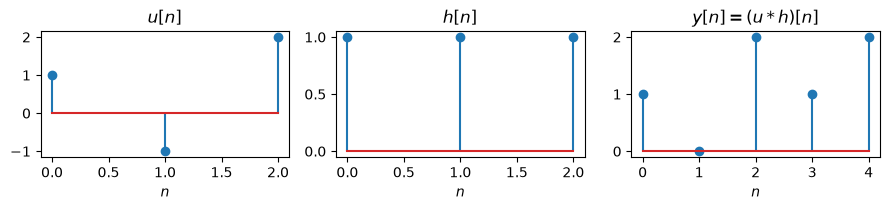

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(9, 2.2))
for ax, (v, t) in zip(axes, [(u, "$u[n]$"), (h, "$h[n]$"), (y, "$y[n] = (u*h)[n]$")]):
    ax.stem(np.arange(len(v)), v)
    ax.set_title(t); ax.set_xlabel("$n$")
plt.tight_layout()

## C2: Step response and a causality check *(↔ P7 and retrieval item 4)*

A sequence is represented by an array of values together with an integer `origin`, the array index that corresponds to $n=0$. The task considers the FIR system with impulse response $h=\{\underset{\uparrow}{1},\,2,\,1\}$.

a) Complete `step_response`: the step response is the running sum $r[n]=\sum_{k\le n} h[k]$ (one numpy call).

b) Complete `is_causal`: an LTI system is causal exactly when every sample of $h$ at $n<0$ vanishes.

In [6]:
def step_response(h):
    """r[n] = sum over k <= n of h[k], for a sequence starting at n = 0."""
    r = np.zeros(len(h))
    total = 0
    for k in range(len(h)):
        total += h[k]
        r[k] = total
    return r   # your code: one numpy call

def is_causal(h, origin):
    """origin is the array index corresponding to n = 0."""
    return bool(np.all(h[:origin] == 0))   # your code: every sample at n < 0 must vanish

In [7]:
h2 = np.array([1, 2, 1])
r = step_response(h2)
assert np.allclose(r, [1, 3, 4])                   # running sum of h
assert np.allclose(np.diff(r, prepend=0), h2)      # h is the backward difference of r
assert is_causal(h2, 0) is True
assert is_causal(np.array([1, 0, 0]), 1) is False  # a nonzero sample at n = -1
print("C2 passed: r is the running sum of h; causality is read off the support of h.")

C2 passed: r is the running sum of h; causality is read off the support of h.


## C3: Partial sums and the limits of numerical testing *(↔ P2, P3, P6)*

The stability test is whether $\sum_k |h[k]|$ is finite; numerically, the sum can be evaluated only up to a finite $N$. This task compares the partial sums $S_N = \sum_{k=0}^{N-1} |h[k]|$ for three impulse responses of this week: the geometric response $(\tfrac13)^k s[k]$ (P2), the unit step (P3), and the harmonic response $\tfrac{1}{k+1}\,s[k]$ (P6).

Complete `partial_sum` and run the table. The partial sums of the geometric response converge rapidly to $\tfrac32$; those of the step grow linearly; those of the harmonic response grow without bound, yet reach only approximately $14.4$ after $10^6$ terms. A finite computation therefore cannot establish whether the series converges; the stability test is decided by analysis.

In [8]:
def partial_sum(h_of_k, N):
    """S_N = sum over k = 0, ..., N-1 of |h[k]|, for h given as a function of k."""
    k = np.arange(N)
    return np.sum(abs(h_of_k(k)))   # your code

geometric = lambda k: (1/3)**k                        # P2: stable
step      = lambda k: np.ones_like(k, dtype=float)    # P3: bounded, not summable
harmonic  = lambda k: 1.0 / (k + 1)                   # P6: decays to zero, not summable

for N in (100, 10_000, 1_000_000):
    row = [partial_sum(h, N) for h in (geometric, step, harmonic)]
    print(f"N = {N:>9,}:  geometric {row[0]:8.4f}   step {row[1]:>12,.0f}   harmonic {row[2]:7.3f}")

N =       100:  geometric   1.5000   step          100   harmonic   5.187
N =    10,000:  geometric   1.5000   step       10,000   harmonic   9.788
N = 1,000,000:  geometric   1.5000   step    1,000,000   harmonic  14.393


In [9]:
assert abs(partial_sum(geometric, 100) - 1.5) < 1e-9      # settled: 1/(1 - 1/3) = 3/2
assert partial_sum(step, 10_000) == 10_000                 # grows linearly: not summable
S4, S6 = partial_sum(harmonic, 10_000), partial_sum(harmonic, 1_000_000)
assert S6 < 15                                             # looks convergent at any practical N ...
assert S6 - S4 > 4                                         # ... yet is still climbing, by about ln(100)
print("C3 passed: finite partial sums cannot prove stability; convergence must be established analytically.")


C3 passed: finite partial sums cannot prove stability; convergence must be established analytically.


## C4: A single echo and a feedback echo *(↔ P6 and the in-class echo unit)*

A single echo adds one delayed copy: $y[n]=u[n]+\alpha\,u[n-D]$, an FIR system with $h=\delta[n]+\alpha\,\delta[n-D]$. A feedback echo adds a delayed copy of its own output: $y[n]=u[n]+\alpha\,y[n-D]$, an IIR system whose impulse response never ends.

Complete the feedback term, then compare the loop gains: for $|\alpha|<1$ the response to the unit impulse decays geometrically; for $|\alpha|>1$ it grows without bound.

In [10]:
D, alpha = 3, 0.6
u4 = np.zeros(12); u4[0] = 1                     # a click

# Single echo (FIR): h = delta[n] + alpha delta[n-D]
h4 = np.zeros(D + 1); h4[0] = 1; h4[D] = alpha
y_fir = np.convolve(u4, h4)[:12]

# Feedback echo (IIR): y[n] = u[n] + alpha y[n-D]
def feedback_echo(u, alpha, D):
    y = np.zeros(len(u))
    for n in range(len(u)):
        y[n] = u[n] + alpha * y[n - D]   # your code: the feedback term (careful with n - D < 0)
    return y


In [11]:
assert y_fir[0] == 1 and y_fir[D] == alpha and np.count_nonzero(y_fir) == 2

u_fb = np.zeros(30); u_fb[0] = 1                 # unit impulse for the feedback-echo tests
y06 = feedback_echo(u_fb, 0.6, 3)
assert abs(y06[27] - 0.6**9) < 1e-12                      # the echoes decay geometrically
assert np.max(np.abs(feedback_echo(u_fb, 1.2, 3))) > 4    # loop gain > 1: the response grows
print("C4 passed: the FIR echo stops; the feedback echo decays or grows with the loop gain.")


C4 passed: the FIR echo stops; the feedback echo decays or grows with the loop gain.


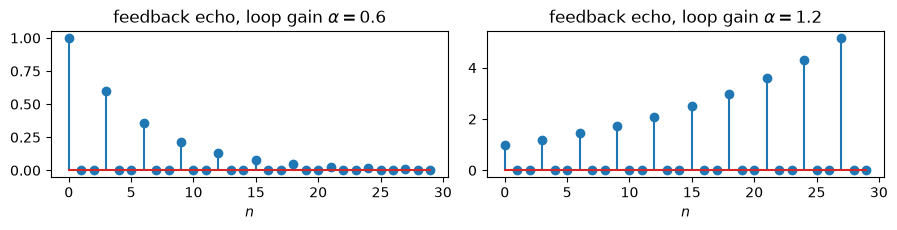

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 2.4), sharex=True)
for ax, a in zip(axes, (0.6, 1.2)):
    y = feedback_echo(u_fb, a, 3)
    ax.stem(np.arange(len(u_fb)), y)
    ax.set_title(f"feedback echo, loop gain $\\alpha = {a}$"); ax.set_xlabel("$n$")
plt.tight_layout()
